In [1]:
! pip install kaggle
! pip install onnx
! pip install dagshub
! pip install mlflow
from google.colab import drive
drive.mount('/content/drive')
! mkdir ~/.kaggle
! cp /content/drive/MyDrive/ColabNotebooks/kaggle_API_credentials/kaggle.json ~/.kaggle/kaggle.json
! chmod 600 ~/.kaggle/kaggle.json
# ! kaggle competitions download -c walmart-recruiting-store-sales-forecasting
# ! unzip walmart-recruiting-store-sales-forecasting

Mounted at /content/drive


In [2]:
# ! unzip test.csv.zip
# ! unzip train.csv.zip
# ! unzip sampleSubmission.csv.zip
# ! unzip features.csv.zip

In [3]:
# ! rm -rf test.csv.zip
# ! rm -rf train.csv.zip
# ! rm -rf sampleSubmission.csv.zip
# ! rm -rf features.csv.zip

In [4]:
# 1. Clone your GitHub repo
!git clone https://github.com/arazm21/ML-final_project

# 2. Add the cloned repo (or specific folder) to sys.path
import sys
sys.path.insert(0, '/content/ML-final_project')


Cloning into 'ML-final_project'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 24 (delta 0), reused 21 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 3.72 MiB | 10.99 MiB/s, done.


In [1]:
import torch # Main PyTorch Library
from torch import nn # Used for creating the layers and loss function
from torch.optim import Adam # Adam Optimizer
import torchvision.transforms as transforms # Transform function used to modify and preprocess all the images
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creating the objects
from sklearn.preprocessing import LabelEncoder # Label Encoder to encode the classes from strings to numbers
import matplotlib.pyplot as plt # Used for visualizing the images and plotting the training progress
from PIL import Image # Used to read the images from the directory
import pandas as pd # Used to read/create dataframes (csv) and process tabular data
import numpy as np # preprocessing and numerical/mathematical operations
import os # Used to read the images path from the directory

device = "cuda" if torch.cuda.is_available() else "cpu" # detect the GPU if any, if not use CPU, change cuda to mps if you have a mac
print("Device available: ", device)

Device available:  cpu


In [69]:
# features_df = pd.read_csv('ML-final_project/data/features.csv/features.csv')
# sample_submission_df = pd.read_csv('ML-final_project/data/sampleSubmission.csv/sampleSubmission.csv')
# test_df = pd.read_csv('ML-final_project/data/test.csv/test.csv')
# train_df = pd.read_csv('ML-final_project/data/train.csv/train.csv')
# stores_df = pd.read_csv('ML-final_project/data/stores.csv')

features_df = pd.read_csv('data/features.csv/features.csv')
sample_submission_df = pd.read_csv('data/sampleSubmission.csv/sampleSubmission.csv')
test_df = pd.read_csv('data/test.csv/test.csv')
train_df = pd.read_csv('data/train.csv/train.csv')
stores_df = pd.read_csv('data/stores.csv')

In [4]:
display(train_df.head())

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [70]:
import pandas as pd

# Use the actual date range present in the data
all_dates = sorted(train_df['Date'].unique())

# Collect filled groups
filled_groups = []

# Process each Store/Dept group
for (store, dept), group in train_df.groupby(['Store', 'Dept']):
    group = group.set_index('Date')

    # Reindex to actual full dates in data
    reindexed = group.reindex(all_dates)
    reindexed.index.name = 'Date'

    # Fill identifying columns
    reindexed['Store'] = store
    reindexed['Dept'] = dept

    # Fill missing sales with 0
    reindexed['Weekly_Sales'] = reindexed['Weekly_Sales'].fillna(0)

    filled_groups.append(reindexed.reset_index())

# Concatenate full DataFrame
train_df_filled = pd.concat(filled_groups).sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)


In [67]:
train_df_filled.to_csv('temp/train_df_filled.csv', index=False)

In [71]:
train_df_filled = train_df_filled.drop(columns=['IsHoliday'], errors='ignore')

# Merge on 'Store' and 'Date'
train_merged = pd.merge(train_df_filled, features_df, on=['Store', 'Date'], how='left')
test_merged = pd.merge(test_df, features_df, on=['Store', 'Date'], how='left')
train_merged = pd.merge(train_merged, stores_df, on='Store', how='left')
test_merged = pd.merge(test_merged, stores_df, on='Store', how='left')

In [72]:
print(train_merged.columns)
print(train_merged.dtypes)
display(train_merged.head())


Index(['Date', 'Store', 'Dept', 'Weekly_Sales', 'Temperature', 'Fuel_Price',
       'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'IsHoliday', 'Type', 'Size'],
      dtype='object')
Date             object
Store             int64
Dept              int64
Weekly_Sales    float64
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
IsHoliday          bool
Type             object
Size              int64
dtype: object


,Date,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Type,Size
0,2010-02-05,1,1,24924.50,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,2010-02-12,1,1,46039.49,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,2010-02-19,1,1,41595.55,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,2010-02-26,1,1,19403.54,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,2010-03-05,1,1,21827.90,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


## helper functions

### 1.feature engineering functions

In [ ]:
def add_holiday_lookahead(df):
    """
    Adds:
    - IsHolidayNextWeek: True if this week OR next week is a holiday.
    - IsHolidayIn2Weeks: True if this week OR next 2 weeks are holidays.
    """
    df = df.sort_values(by=['Store', 'Date']).copy()

    # current and future IsHoliday flags
    curr = df['IsHoliday'].astype(bool)
    next_1 = df.groupby('Store')['IsHoliday'].shift(-1).fillna(False).astype(bool)
    next_2 = df.groupby('Store')['IsHoliday'].shift(-2).fillna(False).astype(bool)

    df['IsHolidayNextWeek'] = (curr | next_1).astype(int)
    df['IsHolidayIn2Weeks'] = (curr | next_1 | next_2).astype(int)

    return df

def add_date_features(df):
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['WeekOfYear'] = df['Date'].dt.isocalendar().week
    # df['Day'] = df['Date'].dt.day
    # df['DayOfWeek'] = df['Date'].dt.weekday  # Monday=0, Sunday=6
    return df

# use this method for model which are not sequencial, i.e.xgboost
def drop_unneeded_columns(df, drop_date=True):
    """
    Drop or convert fields not usable by XGBoost directly.
    """
    df = df.copy()
    if drop_date and 'Date' in df.columns:
        df = df.drop(columns=['Date'])
    return df


## connecting wandb and dagshub

In [17]:
project_name = 'ML-final_project'
run_name = "test_run_1"
repo_owner = "arazm21"

In [18]:
import wandb
wandb.login()

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: arazm21 (arazm21-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [19]:
import dagshub
import mlflow
import mlflow.sklearn
dagshub.init(repo_owner=repo_owner, repo_name=project_name, mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=cd25537e-680f-44a0-9c17-2795377d273b&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=6081d3ccba1aaba46d9c80c9162f53fae7ff11afa8bf92adafb899c73f4b1b7a




Output()

Accessing as arazm21

Initialized MLflow to track repo "arazm21/ML-final_project"

Repository arazm21/ML-final_project initialized!

In [ ]:
# with wandb.init(project=project_name,
#                 config=hyperparameters,
#                 name = run_name):


## getting data ready

3


,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Type,Size
0,1,1,2010-02-05,24924.50,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


## plots

### checking 3 departament/store combinations

143 2010-02-05 00:00:00 2012-10-26 00:00:00
143 2010-02-05 00:00:00 2012-10-26 00:00:00
143 2010-02-05 00:00:00 2012-10-26 00:00:00


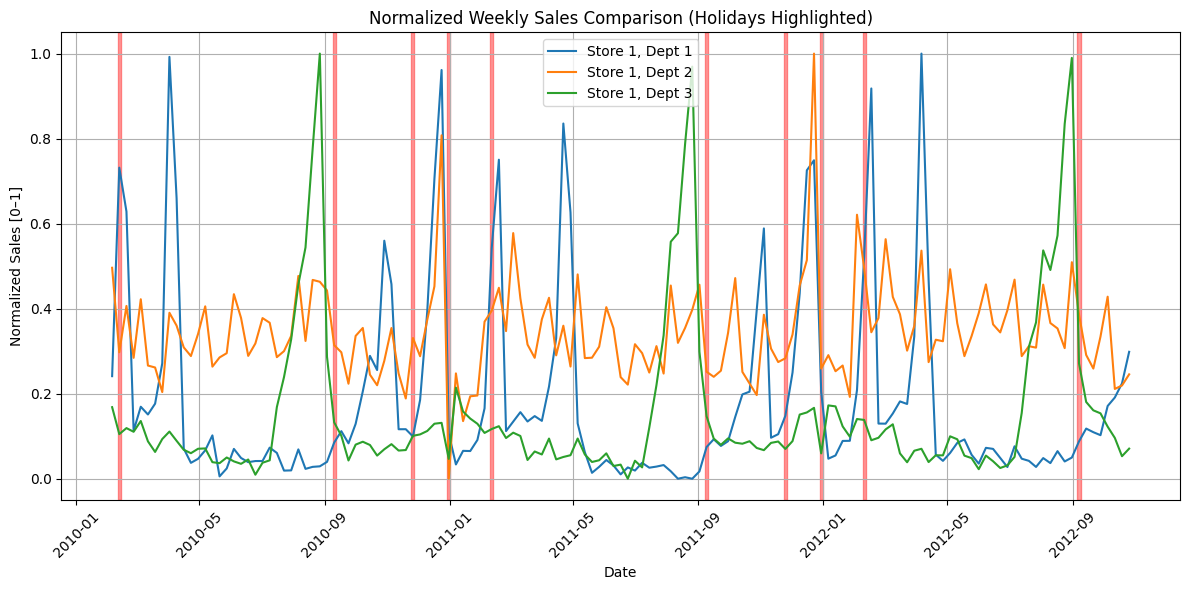

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
train_merged = train_merged.sort_values(['Store', 'Dept', 'Date'])

groups = [g for _, g in train_df.groupby(['Store', 'Dept']) if len(g) > 100]
selected = groups[:3]

selected_series = []
for (store, dept), group in train_merged.groupby(['Store', 'Dept']):
    if len(group) >= 100:
        selected_series.append((store, dept))
        if len(selected_series) == 3:
            break

# Plot normalized series
plt.figure(figsize=(12, 6))
ax = plt.gca()

for i, (store, dept) in enumerate(selected_series):
    series = train_merged[(train_merged['Store'] == store) & 
                          (train_merged['Dept'] == dept)].sort_values('Date').copy()

    series['Date'] = pd.to_datetime(series['Date'])  # 🛠️ Ensure datetime
    print(len(series), series["Date"].iloc[0], series["Date"].iloc[-1])

    # Min-Max normalization
    normalized_sales = (series['Weekly_Sales'] - series['Weekly_Sales'].min()) / \
                       (series['Weekly_Sales'].max() - series['Weekly_Sales'].min())
    
    plt.plot(series['Date'], normalized_sales, label=f"Store {store}, Dept {dept}")

    # Highlight holiday weeks
    holidays = series[series['IsHoliday'] == True]['Date']
    for holiday_date in holidays:
        ax.axvspan(holiday_date - pd.Timedelta(days=1.5),
                   holiday_date + pd.Timedelta(days=1.5),
                   color='red', alpha=0.15)

plt.title('Normalized Weekly Sales Comparison (Holidays Highlighted)')
plt.xlabel('Date')
plt.ylabel('Normalized Sales [0–1]')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [39]:
# Expected sales range differences:
print(train_merged.groupby(['Store','Dept'])['Weekly_Sales'].agg([np.mean, np.std]))

                    mean           std
Store Dept                            
1     1     22513.322937   9854.349032
      2     46102.090420   3440.673222
      3     13150.478042   8708.978853
      4     36964.154476   2930.698313
      5     24257.941119  11330.286495
...                  ...           ...
45    94     3690.272090   1852.287364
      95    52896.166643   5117.961708
      96        2.970000      0.042426
      97     6466.961888    659.739542
      98      561.239037    371.286705

[3331 rows x 2 columns]


C:\Users\alex\AppData\Local\Temp\ipykernel_32772\3343407106.py:2: FutureWarning: The provided callable <function mean at 0x0000021C642AF420> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  print(train_merged.groupby(['Store','Dept'])['Weekly_Sales'].agg([np.mean, np.std]))
C:\Users\alex\AppData\Local\Temp\ipykernel_32772\3343407106.py:2: FutureWarning: The provided callable <function std at 0x0000021C642AF560> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  print(train_merged.groupby(['Store','Dept'])['Weekly_Sales'].agg([np.mean, np.std]))


### trends across all stores/departaments

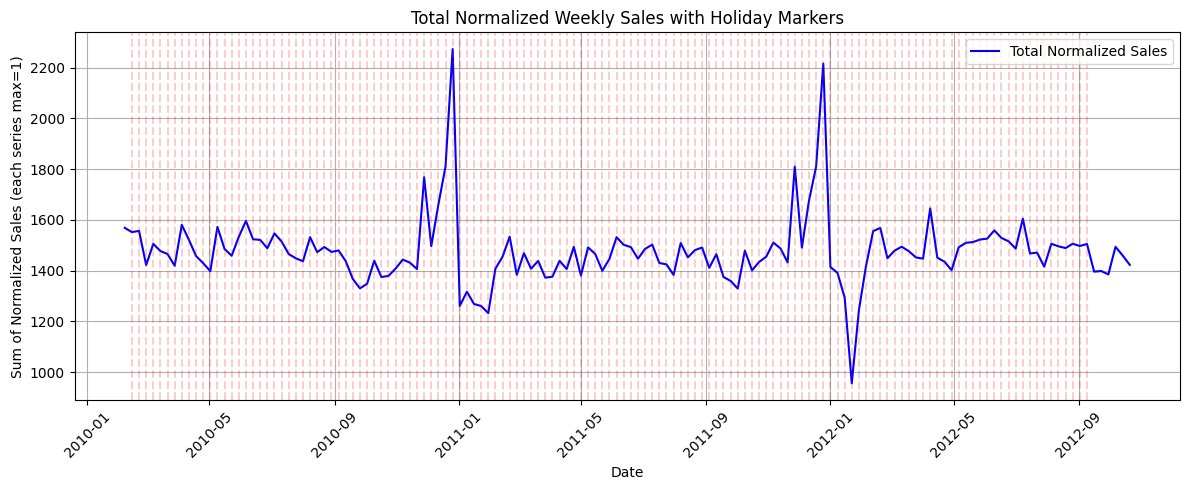

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure Date is datetime
train_merged['Date'] = pd.to_datetime(train_merged['Date'])

# Define common weekly index
common_index = pd.date_range(start=train_merged['Date'].min(),
                             end=train_merged['Date'].max(),
                             freq='W')

# Step 1: Normalize each Store–Dept combo (max = 1)
normalized_series_list = []

for (store, dept), group in train_merged.groupby(['Store', 'Dept']):
    group = group.set_index('Date').sort_index()
    weekly_sales = group['Weekly_Sales'].resample('W').sum()

    max_sales = weekly_sales.max()
    if pd.isna(max_sales) or max_sales == 0:
        continue

    normalized = weekly_sales / max_sales
    normalized = normalized.reindex(common_index).interpolate(limit_direction='both')
    normalized_series_list.append(normalized)

# Step 2: Add all normalized series together
normalized_df = pd.DataFrame(normalized_series_list).T
total_normalized_sales = normalized_df.sum(axis=1)

# Step 3: Get unique holiday weeks (from any store/dept)
holiday_weeks = (
    train_merged[train_merged['IsHoliday'] == True]
    .set_index('Date')
    .resample('W').max()
    .index
)

# Step 4: Plot with holiday lines
plt.figure(figsize=(12, 5))
plt.plot(common_index, total_normalized_sales, color='blue', label='Total Normalized Sales')

# Draw vertical lines for holidays
for date in holiday_weeks:
    plt.axvline(date, color='red', linestyle='--', alpha=0.2)

plt.title('Total Normalized Weekly Sales with Holiday Markers')
plt.xlabel('Date')
plt.ylabel('Sum of Normalized Sales (each series max=1)')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


### each store agains each other (summing departaments)

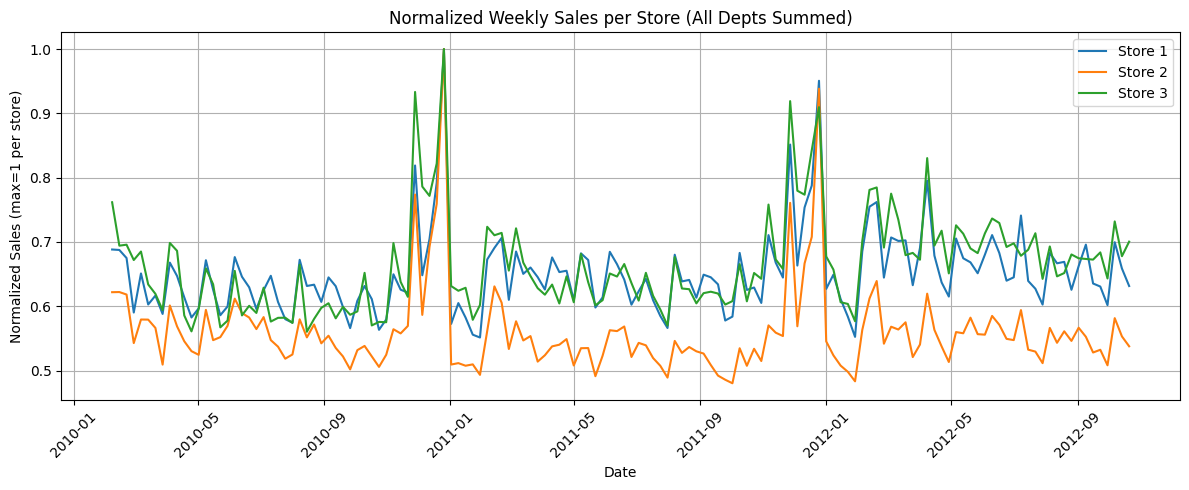

In [49]:
import matplotlib.pyplot as plt

# Set weekly index range
weekly_index = pd.date_range(train_merged['Date'].min(), train_merged['Date'].max(), freq='W')

# Step 1: Group by Store (sum over Depts)
store_series_list = []
store_ids = []

for store, group in train_merged.groupby('Store'):
    group = group.set_index('Date').sort_index()
    weekly_sales = group['Weekly_Sales'].resample('W').sum()

    max_sales = weekly_sales.max()
    if pd.isna(max_sales) or max_sales == 0:
        continue

    normalized = weekly_sales / max_sales
    normalized = normalized.reindex(weekly_index).interpolate(limit_direction='both')
    
    store_series_list.append(normalized)
    store_ids.append(store)

    if len(store_series_list) == 3:
        break

# Plot 3 stores
plt.figure(figsize=(12, 5))
for series, store_id in zip(store_series_list, store_ids):
    plt.plot(weekly_index, series, label=f"Store {store_id}")

plt.title("Normalized Weekly Sales per Store (All Depts Summed)")
plt.xlabel("Date")
plt.ylabel("Normalized Sales (max=1 per store)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### each departament agains each other (summing all stores)

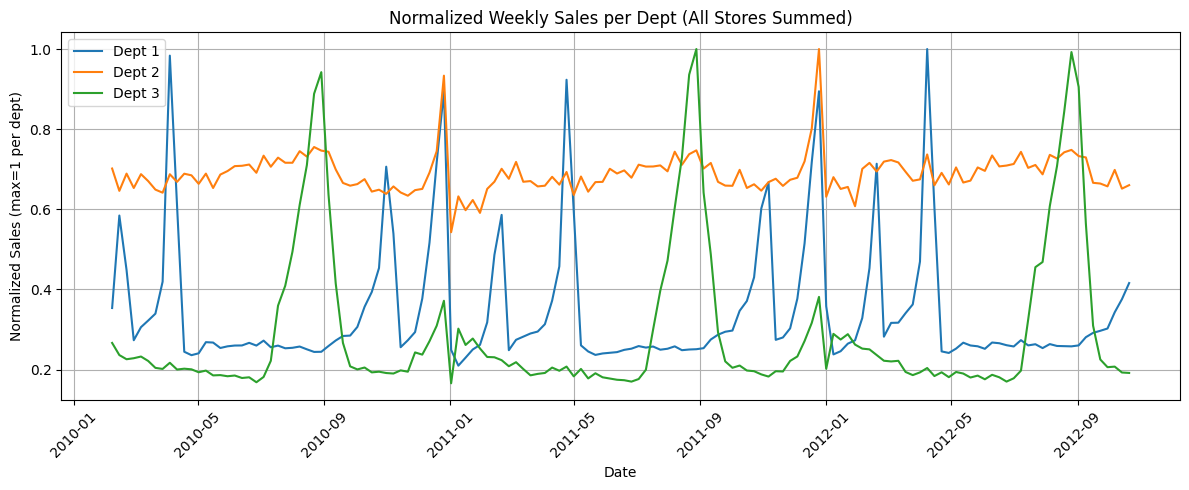

In [50]:
# Step 2: Group by Dept (sum over Stores)
dept_series_list = []
dept_ids = []

for dept, group in train_merged.groupby('Dept'):
    group = group.set_index('Date').sort_index()
    weekly_sales = group['Weekly_Sales'].resample('W').sum()

    max_sales = weekly_sales.max()
    if pd.isna(max_sales) or max_sales == 0:
        continue

    normalized = weekly_sales / max_sales
    normalized = normalized.reindex(weekly_index).interpolate(limit_direction='both')
    
    dept_series_list.append(normalized)
    dept_ids.append(dept)

    if len(dept_series_list) == 3:
        break

# Plot 3 depts
plt.figure(figsize=(12, 5))
for series, dept_id in zip(dept_series_list, dept_ids):
    plt.plot(weekly_index, series, label=f"Dept {dept_id}")

plt.title("Normalized Weekly Sales per Dept (All Stores Summed)")
plt.xlabel("Date")
plt.ylabel("Normalized Sales (max=1 per dept)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## train!!!

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import plotly.express as px


In [57]:
import plotly.express as px
import pandas as pd

def plot_sales(df: pd.DataFrame, store: int, dep: int) -> None:
    """
    Plots weekly sales for a specific store and department.
    
    Parameters:
    - df: Full dataset (like train_merged)
    - store: Store number (int)
    - dep: Department number (int)
    """
    # Ensure datetime
    df['Date'] = pd.to_datetime(df['Date'])

    # Filter for Store and Dept
    combo_df = df[(df['Store'] == store) & (df['Dept'] == dep)].copy()

    if combo_df.empty:
        print(f"No data for Store {store}, Dept {dep}")
        return

    # Aggregate by Date
    combo_df = combo_df.groupby('Date')['Weekly_Sales'].sum().reset_index()
    combo_df.rename(columns={'Weekly_Sales': 'Sales', 'Date': 'Month'}, inplace=True)

    # Plot
    fig = px.line(combo_df, x='Month', y='Sales', labels={'Month': 'Date'})
    fig.update_layout(template="simple_white", font=dict(size=18),
                      title_text=f'Store {store}, Dept {dep} Weekly Sales',
                      width=650, title_x=0.5, height=400)

    return fig.show()


In [58]:
plot_sales(train_merged, store=1, dep=1)


In [59]:
from scipy.stats import boxcox
import pandas as pd
import plotly.express as px

# Ensure datetime
train_merged['Date'] = pd.to_datetime(train_merged['Date'])

# Make a copy to avoid overwriting original
train_boxcox = train_merged.copy()

# New column to store Box-Cox transformed sales
train_boxcox['Sales_Boxcox'] = np.nan

# Dictionary to store lambda for each group (for inverse later)
boxcox_lambdas = {}

# Apply Box-Cox per (Store, Dept)
for (store, dept), group in train_boxcox.groupby(['Store', 'Dept']):
    sales = group['Weekly_Sales'].clip(lower=1)  # avoid 0 or negative
    try:
        transformed, lam = boxcox(sales)
        train_boxcox.loc[group.index, 'Sales_Boxcox'] = transformed
        boxcox_lambdas[(store, dept)] = lam
    except Exception as e:
        print(f"Skipping Store {store}, Dept {dept} due to Box-Cox error: {e}")


Skipping Store 3, Dept 78 due to Box-Cox error: Data must not be constant.
Skipping Store 3, Dept 83 due to Box-Cox error: Data must not be constant.
Skipping Store 4, Dept 39 due to Box-Cox error: Data must not be constant.
Skipping Store 5, Dept 78 due to Box-Cox error: Data must not be constant.
Skipping Store 7, Dept 78 due to Box-Cox error: Data must not be constant.
Skipping Store 7, Dept 99 due to Box-Cox error: Data must not be constant.
Skipping Store 10, Dept 77 due to Box-Cox error: Data must not be constant.
Skipping Store 12, Dept 99 due to Box-Cox error: Data must not be constant.
Skipping Store 13, Dept 43 due to Box-Cox error: Data must not be constant.
Skipping Store 13, Dept 77 due to Box-Cox error: Data must not be constant.
Skipping Store 14, Dept 43 due to Box-Cox error: Data must not be constant.
Skipping Store 15, Dept 37 due to Box-Cox error: Data must not be constant.
Skipping Store 15, Dept 43 due to Box-Cox error: Data must not be constant.
Skipping Store 15,

In [74]:
# Example: Plot original vs. transformed for (Store 1, Dept 1)
sample = train_boxcox[(train_boxcox['Store'] == 1) & (train_boxcox['Dept'] == 2)].copy()

fig = px.line(sample, x='Date', y='Weekly_Sales', title='Original Sales - Store 1, Dept 1')
fig.show()

fig = px.line(sample, x='Date', y='Sales_Boxcox', title='Box-Cox Transformed Sales - Store 1, Dept 1')
fig.show()


In [80]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

def plot_acf_pacf(df: pd.DataFrame, store: int, dept: int) -> None:
    """
    Plots ACF and PACF of Box-Cox differenced Weekly Sales
    for a given Store and Dept.

    Parameters:
    - df: DataFrame with 'Sales_Boxcox' column
    - store: store number
    - dept: department number
    """

    # Filter for store/dept
    series = df[(df['Store'] == store) & (df['Dept'] == dept)].copy()

    if series.empty:
        print(f"No data for Store {store}, Dept {dept}")
        return

    # Drop NaNs in transformed sales
    series = series[['Date', 'Sales_Boxcox']].dropna().sort_values('Date')

    # Apply first difference
    series['Diff'] = series['Sales_Boxcox'].diff().dropna()

    if series['Diff'].dropna().empty:
        print(f"Not enough data to difference for Store {store}, Dept {dept}")
        return

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), dpi=100)

    plot_acf(series['Diff'].dropna(), ax=ax1, lags=60)
    plot_pacf(series['Diff'].dropna(), ax=ax2, lags=60, method='ywm')

    ax1.set_title(f'ACF - Store {store}, Dept {dept}', fontsize=14)
    ax2.set_title(f'PACF - Store {store}, Dept {dept}', fontsize=14)

    ax1.tick_params(axis='both', labelsize=12)
    ax2.tick_params(axis='both', labelsize=12)
    plt.tight_layout()
    plt.show()


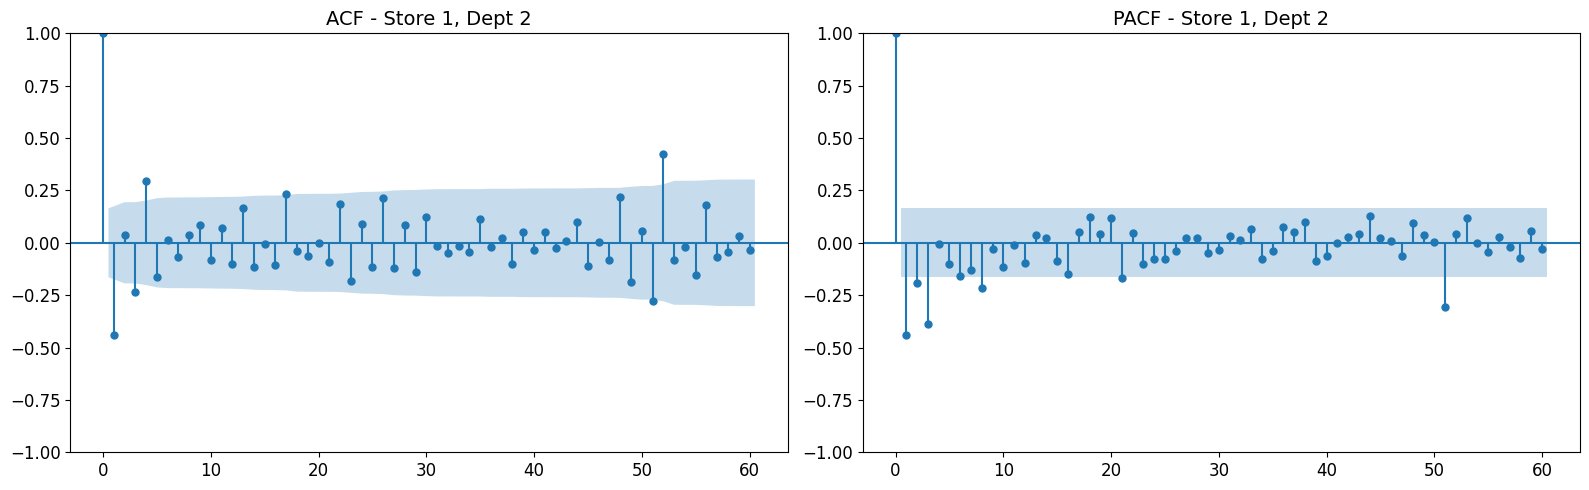

In [82]:
plot_acf_pacf(train_boxcox, store=1, dept=2)


In [92]:
from statsmodels.tsa.arima.model import ARIMA
from scipy.special import inv_boxcox
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Store forecasts
arima_forecasts = {}

# Group-level sizes in original dataset (before filling!)
min_required_points = 120
combo_lengths = train_df.groupby(['Store', 'Dept']).size()

# List of combos to iterate over
eligible_combos = [combo for combo in train_boxcox.groupby(['Store', 'Dept']).groups
                   if combo_lengths.get(combo, 0) >= min_required_points]
limited_combos = eligible_combos[:5]

# Use tqdm for progress tracking
for (store, dept) in tqdm(limited_combos, desc="Training ARIMA models"):
    
    group = train_boxcox[(train_boxcox['Store'] == store) & (train_boxcox['Dept'] == dept)]
    series = group.sort_values('Date')[['Date', 'Sales_Boxcox']].dropna().reset_index(drop=True)
    
    if len(series) < 60:  # still need enough post-Box-Cox
        continue

    # Train-validation split: 80% train, 20% test
    split_idx = int(len(series) * 0.8)
    train_data = series.iloc[:split_idx]
    val_data = series.iloc[split_idx:]

    try:
        # ARIMA with annual seasonality and MA component
        model = ARIMA(train_data['Sales_Boxcox'], order=(52, 1, 28))
        model_fit = model.fit()

        # Forecast for validation period
        boxcox_preds = model_fit.forecast(steps=len(val_data))

        # Inverse Box-Cox
        lam = boxcox_lambdas.get((store, dept), None)
        if lam is None:
            continue  # no lambda = can't inverse
        preds = inv_boxcox(boxcox_preds, lam)

        # Store for analysis/plotting
        arima_forecasts[(store, dept)] = {
            'dates': val_data['Date'].values,
            'y_true': inv_boxcox(val_data['Sales_Boxcox'].values, lam),
            'y_pred': preds
        }

    except Exception as e:
        print(f"Skipping Store {store}, Dept {dept} due to ARIMA error: {e}")


Training ARIMA models:   0%|          | 0/5 [00:00<?, ?it/s]C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

Training ARIMA models:  20%|██        | 1/5 [00:23<01:35, 23.95s/it]C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

C:\Users\alex\Documents\university_work\ML\ML-final_project\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check m

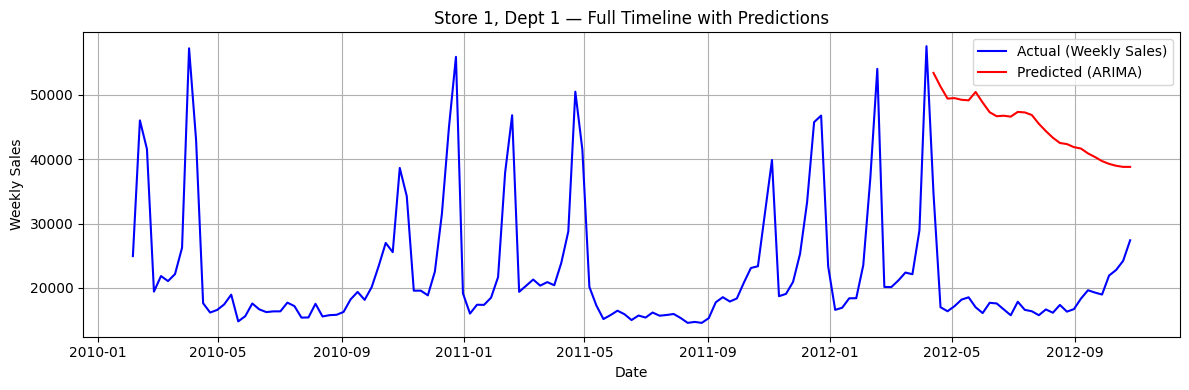

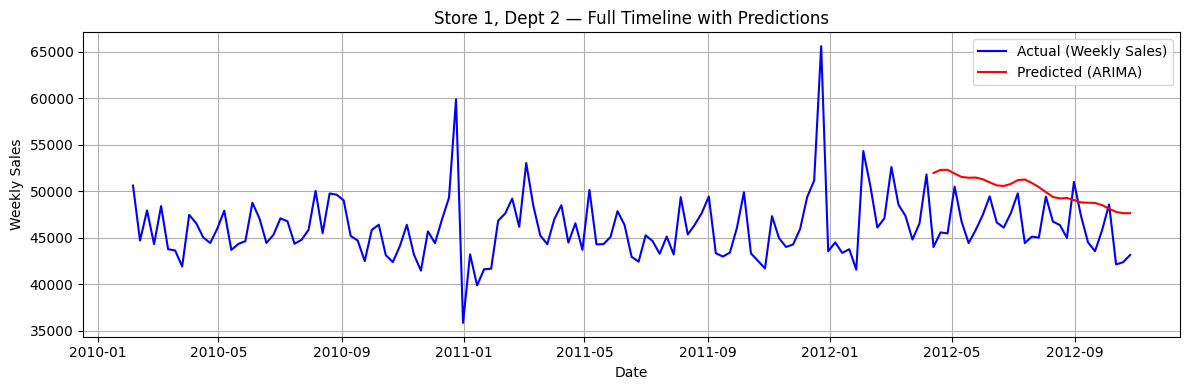

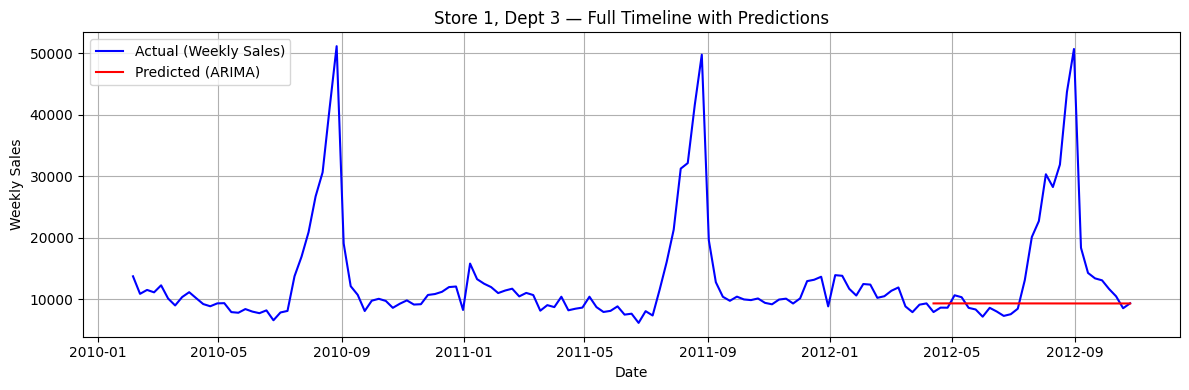

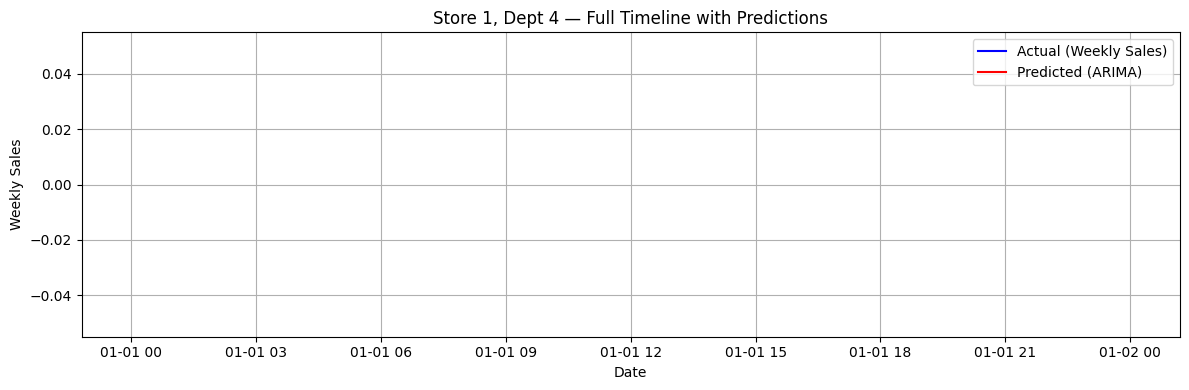

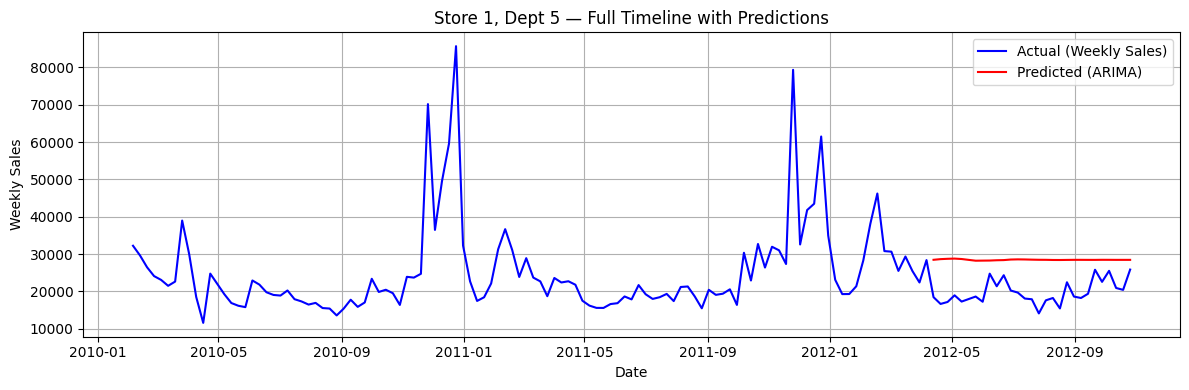

In [94]:
for (store, dept), result in arima_forecasts.items():
    # Retrieve the full original series
    full_series = train_boxcox[
        (train_boxcox['Store'] == store) & (train_boxcox['Dept'] == dept)
    ].sort_values('Date')

    # Recover inverse Box-Cox of full sales
    lam = boxcox_lambdas.get((store, dept), None)
    if lam is None:
        continue
    
    full_sales = inv_boxcox(full_series['Sales_Boxcox'].dropna(), lam)
    full_dates = full_series['Date'].dropna()

    # Determine where prediction starts (validation start index)
    val_start_date = result['dates'][0]

    # Plot full actual series
    plt.figure(figsize=(12, 4))
    plt.plot(full_dates, full_sales, label='Actual (Weekly Sales)', color='blue')

    # Plot predicted values starting from validation start
    plt.plot(result['dates'], result['y_pred'], label='Predicted (ARIMA)', color='red')

    # Visual polish
    plt.title(f"Store {store}, Dept {dept} — Full Timeline with Predictions")
    plt.xlabel("Date")
    plt.ylabel("Weekly Sales")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_forecast_combo(store: int, dept: int):
    result = arima_forecasts.get((store, dept))
    if not result:
        print(f"No forecast for Store {store}, Dept {dept}")
        return

    plt.figure(figsize=(10, 4))
    plt.plot(result['dates'], result['y_true'], label='Actual', color='blue')
    plt.plot(result['dates'], result['y_pred'], label='Predicted', color='red')
    plt.title(f'Store {store}, Dept {dept} – Forecast vs Actual')
    plt.xlabel('Date')
    plt.ylabel('Weekly Sales')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
plot_forecast_combo(1, 1)
plot_forecast_combo(2, 5)
plot_forecast_combo(20, 7)
